In [ ]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\evy12\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset (make sure 'amazon_alexa.tsv' is in the same directory)
try:
    df = pd.read_csv('amazon_alexa.tsv', sep='\t')
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("Error: 'amazon_alexa.tsv' not found. Please ensure the file is in the correct directory.")
    # You might want to exit or handle this more gracefully
    exit()

print("\n--- First 5 rows of the dataset ---")
print(df.head())

print("\n--- Dataset Info ---")
df.info()

print("\n--- Statistical Summary ---")
print(df.describe())

Dataset loaded successfully!

--- First 5 rows of the dataset ---
   rating       date         variation  \
0       5  31-Jul-18  Charcoal Fabric    
1       5  31-Jul-18  Charcoal Fabric    
2       4  31-Jul-18    Walnut Finish    
3       5  31-Jul-18  Charcoal Fabric    
4       5  31-Jul-18  Charcoal Fabric    

                                    verified_reviews  feedback  
0                                      Love my Echo!         1  
1                                          Loved it!         1  
2  Sometimes while playing a game, you can answer...         1  
3  I have had a lot of fun with this thing. My 4 ...         1  
4                                              Music         1  

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   rating            3150 non-null   int64 
 1   date              31

In [ ]:
print("\n--- Missing values per column ---")
print(df.isnull().sum())

# Handle missing values: The video mentions a single null record, so dropping it is fine.
# If you have many, consider imputation or other strategies.
df.dropna(inplace=True)
print(f"\nShape after dropping nulls: {df.shape}")


--- Missing values per column ---
rating              0
date                0
variation           0
verified_reviews    1
feedback            0
dtype: int64

Shape after dropping nulls: (3149, 5)


In [ ]:
# Create a new column for the length of the verified reviews
df['length'] = df['verified_reviews'].apply(len)

print("\n--- First 5 rows with 'length' column ---")
print(df.head())

print("\n--- Description of 'length' column ---")
print(df['length'].describe())


--- First 5 rows with 'length' column ---
   rating       date         variation  \
0       5  31-Jul-18  Charcoal Fabric    
1       5  31-Jul-18  Charcoal Fabric    
2       4  31-Jul-18    Walnut Finish    
3       5  31-Jul-18  Charcoal Fabric    
4       5  31-Jul-18  Charcoal Fabric    

                                    verified_reviews  feedback  length  
0                                      Love my Echo!         1      13  
1                                          Loved it!         1       9  
2  Sometimes while playing a game, you can answer...         1     195  
3  I have had a lot of fun with this thing. My 4 ...         1     172  
4                                              Music         1       5  

--- Description of 'length' column ---
count    3149.000000
mean      132.090187
std       182.114569
min         1.000000
25%        30.000000
50%        74.000000
75%       165.000000
max      2851.000000
Name: length, dtype: float64



--- Distribution of Ratings ---
rating
5    2286
4     455
1     161
3     152
2      95
Name: count, dtype: int64


C:\Users\evy12\AppData\Local\Temp\ipykernel_22656\3921716091.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=df, palette='viridis')


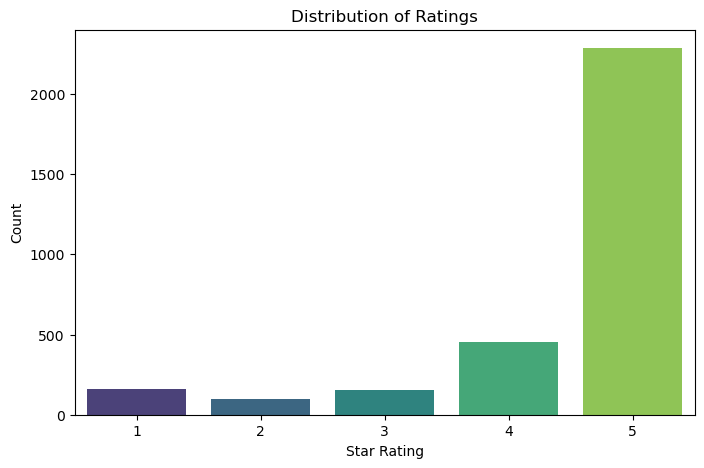


--- Distribution of Feedback ---
feedback
1    2893
0     256
Name: count, dtype: int64


C:\Users\evy12\AppData\Local\Temp\ipykernel_22656\3921716091.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='feedback', data=df, palette='pastel')


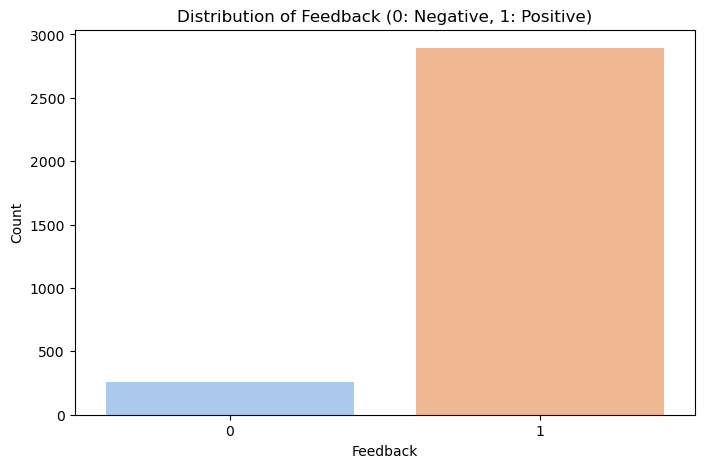


--- Average Rating by Feedback ---
feedback
0    1.371094
1    4.737643
Name: rating, dtype: float64


In [ ]:
# Analyze the distribution of ratings
print("\n--- Distribution of Ratings ---")
print(df['rating'].value_counts())
plt.figure(figsize=(8, 5))
sns.countplot(x='rating', data=df, palette='viridis')
plt.title('Distribution of Ratings')
plt.xlabel('Star Rating')
plt.ylabel('Count')
plt.show()

# Analyze the distribution of feedback (0: Negative, 1: Positive)
print("\n--- Distribution of Feedback ---")
print(df['feedback'].value_counts())
plt.figure(figsize=(8, 5))
sns.countplot(x='feedback', data=df, palette='pastel')
plt.title('Distribution of Feedback (0: Negative, 1: Positive)')
plt.xlabel('Feedback')
plt.ylabel('Count')
plt.show()

# Relationship between rating and feedback
print("\n--- Average Rating by Feedback ---")
print(df.groupby('feedback')['rating'].mean())


--- Average Review Length by Feedback ---
feedback
0    216.066406
1    124.659177
Name: length, dtype: float64


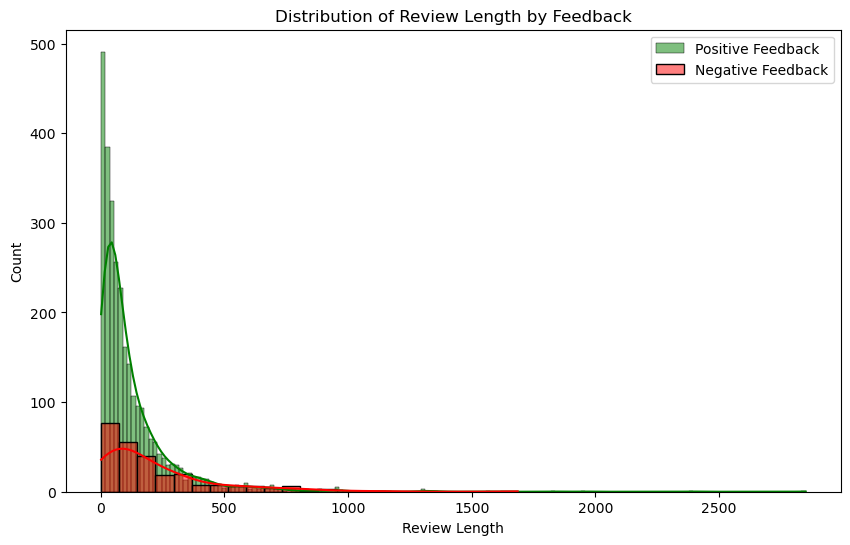

In [ ]:
# Compare average review length for positive and negative feedback
print("\n--- Average Review Length by Feedback ---")
print(df.groupby('feedback')['length'].mean())

plt.figure(figsize=(10, 6))
sns.histplot(df[df['feedback']==1]['length'], color='green', label='Positive Feedback', kde=True)
sns.histplot(df[df['feedback']==0]['length'], color='red', label='Negative Feedback', kde=True)
plt.title('Distribution of Review Length by Feedback')
plt.xlabel('Review Length')
plt.ylabel('Count')
plt.legend()
plt.show()

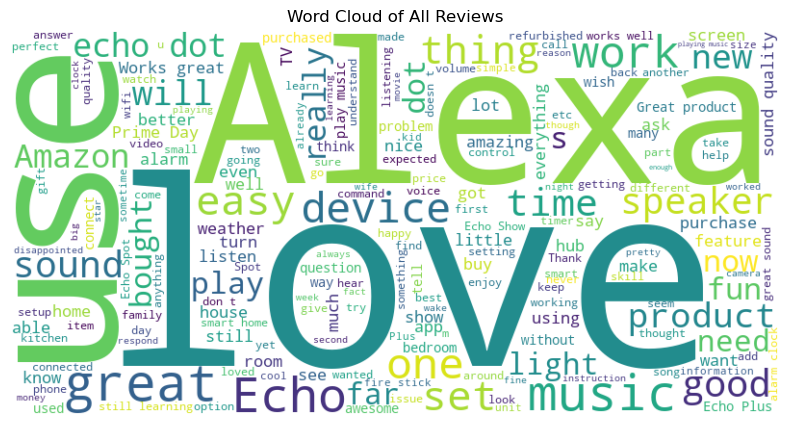

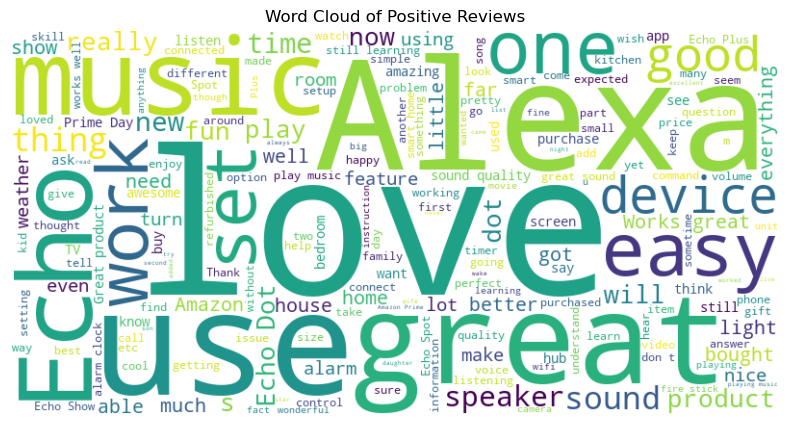

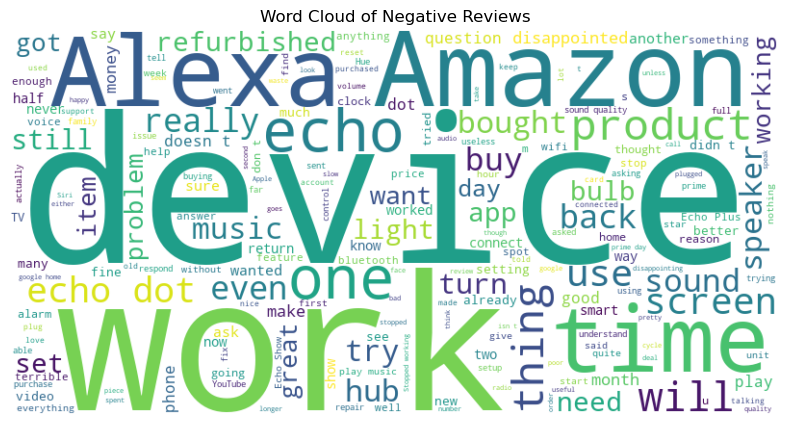

In [ ]:
from wordcloud import WordCloud, STOPWORDS

# Combine all reviews into one string
all_reviews = " ".join(review for review in df['verified_reviews'])

# Create word cloud for all reviews
wordcloud_all = WordCloud(width=800, height=400, background_color='white', stopwords=set(STOPWORDS)).generate(all_reviews)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_all, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of All Reviews')
plt.show()

# Separate reviews by feedback
positive_reviews = " ".join(review for review in df[df['feedback']==1]['verified_reviews'])
negative_reviews = " ".join(review for review in df[df['feedback']==0]['verified_reviews'])

# Word cloud for positive reviews
wordcloud_positive = WordCloud(width=800, height=400, background_color='white', stopwords=set(STOPWORDS)).generate(positive_reviews)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_positive, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Positive Reviews')
plt.show()

# Word cloud for negative reviews
wordcloud_negative = WordCloud(width=800, height=400, background_color='white', stopwords=set(STOPWORDS)).generate(negative_reviews)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_negative, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Negative Reviews')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
# stratify=y is important here because our 'feedback' target is imbalanced.
# It ensures both train and test sets have similar proportions of positive/negative feedback.

print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\n--- Distribution of feedback in training set ---")
print(y_train.value_counts(normalize=True))
print("\n--- Distribution of feedback in test set ---")
print(y_test.value_counts(normalize=True))


X_train shape: (2204, 1500)
X_test shape: (945, 1500)
y_train shape: (2204,)
y_test shape: (945,)

--- Distribution of feedback in training set ---
feedback
1    0.918784
0    0.081216
Name: proportion, dtype: float64

--- Distribution of feedback in test set ---
feedback
1    0.918519
0    0.081481
Name: proportion, dtype: float64


In [ ]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# Save the scaler for later use in the Flask app (for new predictions)
pickle.dump(sc, open('scaler.pkl', 'wb'))
print("\n'scaler.pkl' saved successfully.")


'scaler.pkl' saved successfully.



--- Training XGBoost Classifier ---


C:\Users\evy12\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [15:24:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training complete!

--- Model Evaluation (XGBoost) ---
Accuracy: 0.9365

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.30      0.43        77
           1       0.94      0.99      0.97       868

    accuracy                           0.94       945
   macro avg       0.87      0.65      0.70       945
weighted avg       0.93      0.94      0.92       945



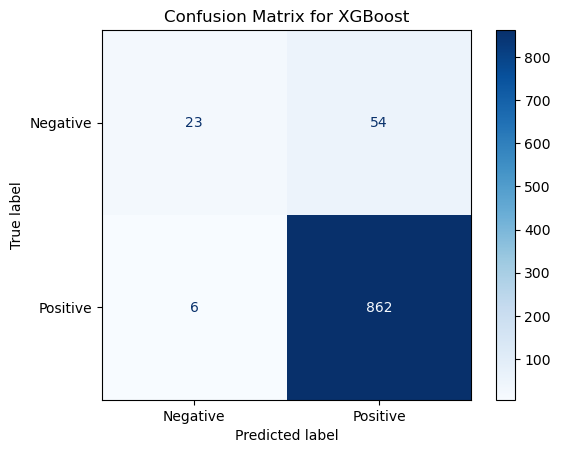

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Initialize and train the XGBoost classifier
# use_label_encoder=False and eval_metric='logloss' are to suppress warnings in newer XGBoost versions
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
print("\n--- Training XGBoost Classifier ---")
xgb_model.fit(X_train, y_train)
print("Training complete!")

# Make predictions on the test set
y_pred = xgb_model.predict(X_test)

# Evaluate the model
print("\n--- Model Evaluation (XGBoost) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for XGBoost')
plt.show()

In [ ]:
# Save the trained XGBoost model
pickle.dump(xgb_model, open('sentiment_model.pkl', 'wb'))
print("\n'sentiment_model.pkl' saved successfully.")


'sentiment_model.pkl' saved successfully.


In [2]:
# ==========================================
# IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix
import plotly.express as px

# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_csv("amazon_alexa.tsv", sep='\t')

df.head()

,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1


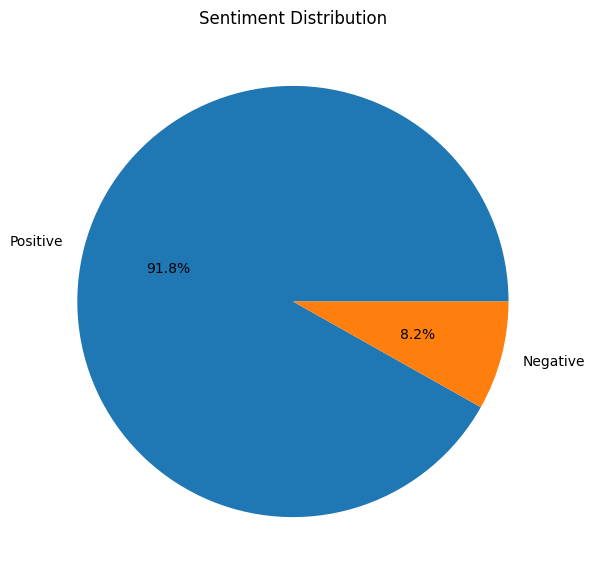

In [3]:
plt.figure(figsize=(7,7))

df['feedback'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    labels=['Positive', 'Negative']
)

plt.title("Sentiment Distribution")

plt.ylabel("")

plt.show()

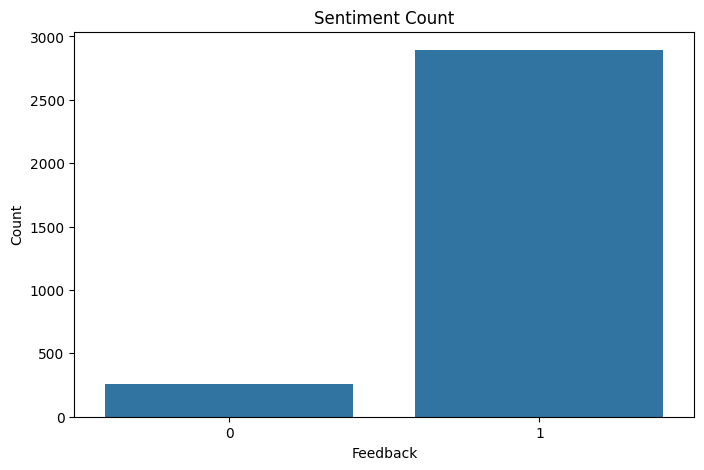

In [4]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='feedback',
    data=df
)

plt.title("Sentiment Count")

plt.xlabel("Feedback")

plt.ylabel("Count")

plt.show()

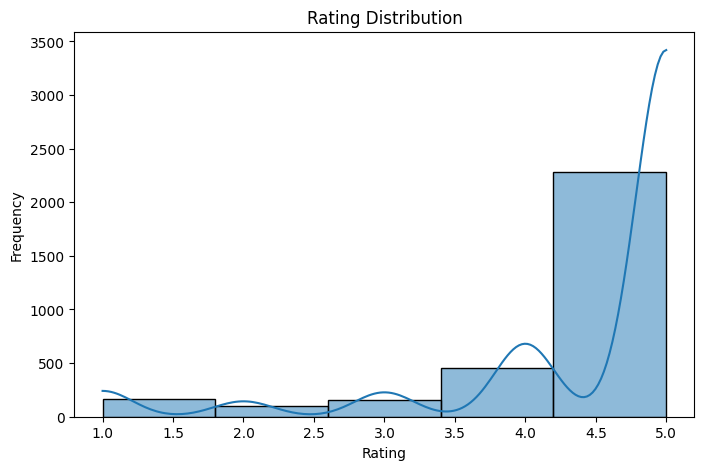

In [5]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['rating'],
    bins=5,
    kde=True
)

plt.title("Rating Distribution")

plt.xlabel("Rating")

plt.ylabel("Frequency")

plt.show()

In [6]:
total_reviews = len(df)

positive_reviews = len(df[df['feedback'] == 1])

negative_reviews = len(df[df['feedback'] == 0])

print("Total Reviews :", total_reviews)

print("Positive Reviews :", positive_reviews)

print("Negative Reviews :", negative_reviews)

Total Reviews : 3150
Positive Reviews : 2893
Negative Reviews : 257


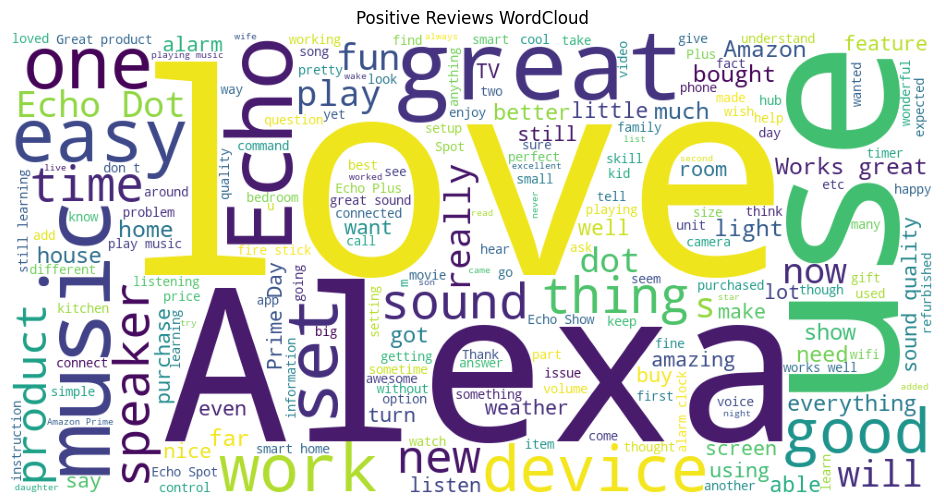

In [7]:
positive_text = " ".join(
    df[df['feedback'] == 1]['verified_reviews'].astype(str)
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis('off')

plt.title("Positive Reviews WordCloud")

plt.show()

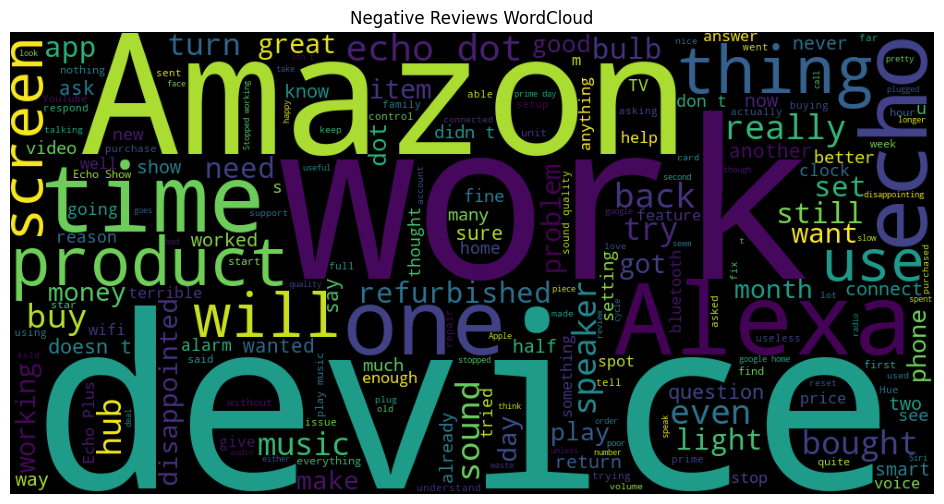

In [8]:
negative_text = " ".join(
    df[df['feedback'] == 0]['verified_reviews'].astype(str)
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='black'
).generate(negative_text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis('off')

plt.title("Negative Reviews WordCloud")

plt.show()

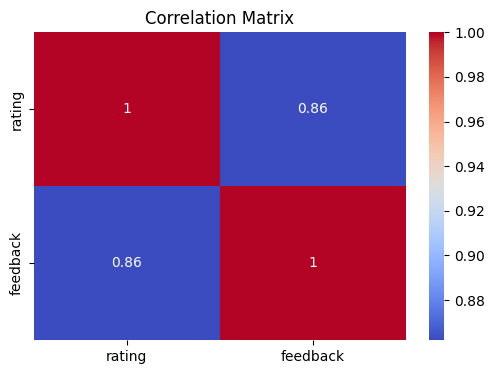

In [9]:
plt.figure(figsize=(6,4))

corr = df[['rating', 'feedback']].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

In [10]:
vectorizer = TfidfVectorizer(stop_words='english')

X = vectorizer.fit_transform(
    df['verified_reviews'].astype(str)
)

kmeans = KMeans(
    n_clusters=2,
    random_state=42
)

clusters = kmeans.fit_predict(X)

df['Cluster'] = clusters

print(df[['verified_reviews', 'Cluster']].head())

                                    verified_reviews  Cluster
0                                      Love my Echo!        1
1                                          Loved it!        1
2  Sometimes while playing a game, you can answer...        1
3  I have had a lot of fun with this thing. My 4 ...        0
4                                              Music        0


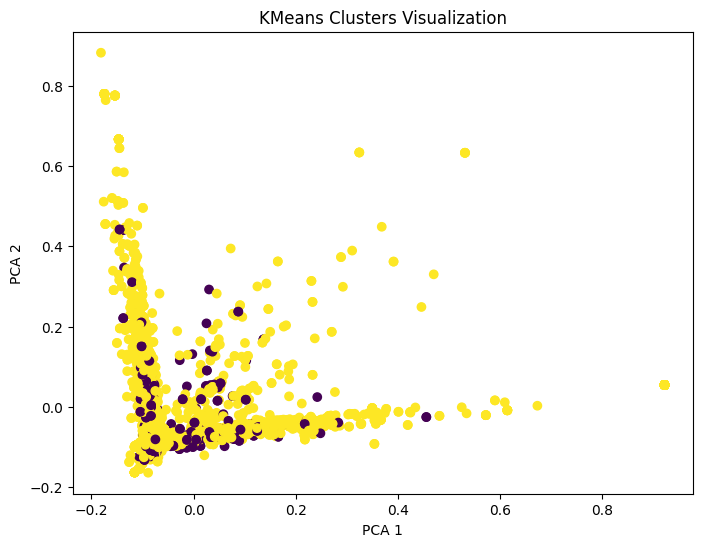

In [11]:
pca = PCA(n_components=2)

reduced = pca.fit_transform(X.toarray())

plt.figure(figsize=(8,6))

plt.scatter(
    reduced[:,0],
    reduced[:,1],
    c=clusters
)

plt.title("KMeans Clusters Visualization")

plt.xlabel("PCA 1")

plt.ylabel("PCA 2")

plt.show()

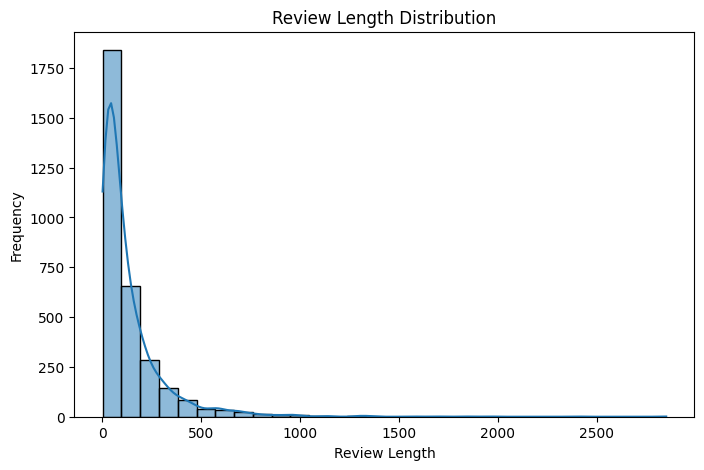

In [15]:
df['review_length'] = df['verified_reviews'].astype(str).apply(len)

plt.figure(figsize=(8,5))

sns.histplot(
    df['review_length'],
    bins=30,
    kde=True
)

plt.title("Review Length Distribution")

plt.xlabel("Review Length")

plt.ylabel("Frequency")

plt.show()

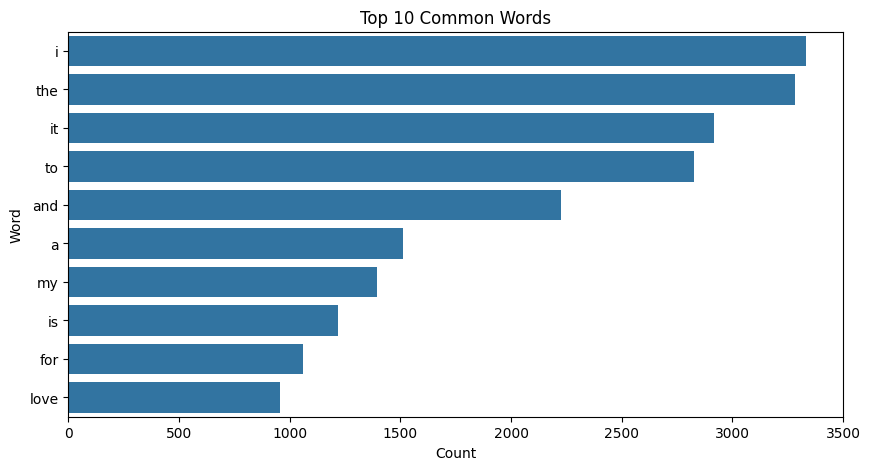

In [16]:
from collections import Counter
import re

text = " ".join(df['verified_reviews'].astype(str))

words = re.findall(r'\w+', text.lower())

common_words = Counter(words).most_common(10)

common_df = pd.DataFrame(
    common_words,
    columns=['Word', 'Count']
)

plt.figure(figsize=(10,5))

sns.barplot(
    x='Count',
    y='Word',
    data=common_df
)

plt.title("Top 10 Common Words")

plt.show()

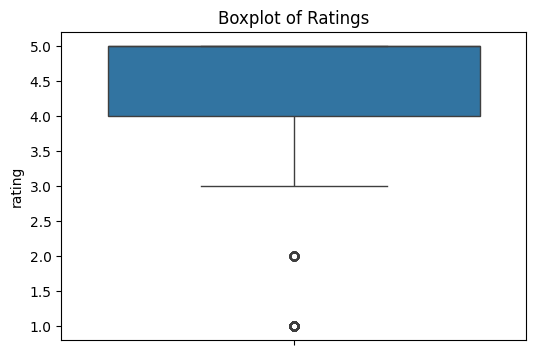

In [17]:
plt.figure(figsize=(6,4))

sns.boxplot(
    y=df['rating']
)

plt.title("Boxplot of Ratings")

plt.show()

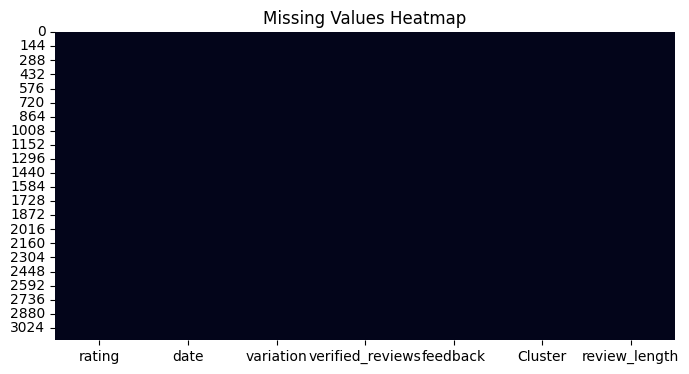

In [18]:
plt.figure(figsize=(8,4))

sns.heatmap(
    df.isnull(),
    cbar=False
)

plt.title("Missing Values Heatmap")

plt.show()